Challenge Data Scientist

Author: Guilherme Garcia Paschoalinoto

Description:
Evaluate the candidate's ability to work with a real-world dataset, perform exploratory data analysis (EDA), preprocess data, build and evaluate a classification model, and interpret the results.

Deliverables:
The submission consists of Python code that is reproducible, in the format most suitable for the candidate (notebooks or scripts). Since the data is public, the submission can be code files, a shared GitHub link, or a shared Kaggle/Colab link. Submit a report or slides to be presented in a new session of up to 30 minutes, plus 15 minutes for discussion.

# Import Libraries

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, roc_curve, average_precision_score
import shap
from sklearn.feature_selection import SelectFromModel

import pickle

# Dataset

The dataset contains information on marketing campaigns from a Portuguese banking institution. The goal is to predict whether a client will subscribe to a term deposit. There are over 40,000 examples with variables and a target.

Dataset URL: https://www.kaggle.com/datasets/abdelazizsami/bank-marketing/data

In [2]:
dataset_path = kagglehub.dataset_download("abdelazizsami/bank-marketing")

csv_path = f"{dataset_path}/bank-full.csv"
df = pd.read_csv(csv_path, sep=';', encoding='latin1')

print('Dataframe length:', df.shape)
df.head()

Dataframe length: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Predictive Modeling

After a thorough understanding of the data through exploratory analysis, the predictive modeling phase focuses on building, evaluating, and refining machine learning models to uncover meaningful patterns and predict future outcomes.

During this process, various algorithms are tested and compared to identify the one that best balances interpretability and performance. Key steps include data preprocessing, handling class imbalance, feature selection, model training and hyperparameter tuning, and performance evaluation using appropriate metrics. In this project, the goal is to predict whether a client will subscribe to a term deposit, enabling more efficient targeting strategies and improving the success rate of future marketing campaigns.

## Train Test Split

In [3]:
df_train_test = df.sample(frac= 0.95, random_state=42)
df_validate = df.drop(df_train_test.index)

df_train_test.reset_index(drop=True, inplace= True)
df_validate.reset_index(drop=True, inplace= True)

print('95% of data for modeling:', df_train_test.shape)
print('05% of data for validate:', df_validate.shape)

X = df_train_test.drop(columns=['y', 'duration'], axis=1)
y = df_train_test['y'].map({'no': 0,
                            'yes':1})

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y
)

print('\nTraining data:', X_train.shape, y_train.shape)
print('Testing data:', X_test.shape, y_test.shape)

df_validate.drop(columns=['duration']).to_csv('./deploy/data/df_validate.csv', sep=',', index=False)

95% of data for modeling: (42950, 17)
05% of data for validate: (2261, 17)

Training data: (34360, 15) (34360,)
Testing data: (8590, 15) (8590,)


## Preprocessing

### Scaling

#### Continuous Features

To address the numerical features that exhibited, during the exploratory data analysis, significant skewness and the presence of outliers, RobustScaler was selected as the scaling method for the following reason: It scales data using statistics as the median and the interquantile range (IQR) that are robust to outliers. This ensures that the scaling of the main distribution is not influenced by extreme values, providing a more representative and stable feature set for the models.

This characteristic makes standard scaling methods, like StandardScaler, less suitable as they are sensitive to the mean and standard deviation, which are easily distorted by extreme values.

This preprocessing step will be applied selectively for linear models and distance-based (Logistic Regression, KNN) and will be omitted for tree-based ensemble models (Random Forest, LGBM, XGBClassifier), as they are insensitive to the scale of these features.

In [4]:
continuous_vars = ['age', 'balance', 'campaign', 'pdays', 'previous']

numeric_transformer = RobustScaler()

### Encoding

#### Nominal Features

To address the nominal features and binary features, the OneHotEncoder will be applied. This method converts each category into a new, separate binary (1 or 0) column. This approach is ideal because it allows the model to understand the categorical data numerically without creating a false or artificial sense of order.

Additionally, the drop_first=True parameter was used in this process. This removes one binary column from each original feature, which is considered a best practice to avoid data redundancy and to prevent multicollinearity. The information of the dropped column is implicitly captured when all other columns for that feature are zero.

In [5]:
nominal_vars = ['job', 'marital', 'contact', 'poutcome', 'default', 'housing', 'loan']

nominal_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

#### Ordinal Features

For categorical ordinal features that possess a natural and meaningful order, such as education and month, the OrdinalEncoding strategy was chosen. This method provides the model with valuable contextual information about the feature's progression into a sequence of integers, which can lead to better predictive performance.

In [6]:
ordinal_vars = ['education', 'month']

education_order = ['primary', 'secondary', 'tertiary', 'unknown']
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

ordinal_transformer = OrdinalEncoder(categories=[education_order, month_order])

## Models Comparison

### Logistic Regression

Logistic Regression was implemented as the foundational baseline model for this project. Although the Exploratory Data Analysis (EDA) did not indicate a clear linear relationship between the features and the target variable, and the data did not follow a normal distribution, this model serves as a benchmark for performance and interpretability.

To maximize its potential and address the model's requirements, the following preprocessing pipeline was applied before training with KFold:

Feature Scaling: Continuous variables were scaled using StandardScaler, an important step for regularized linear models to ensure that all features contribute fairly to the outcome, regardless of their original scale.

Feature Encoding: OneHotEncoder and OrdinalEncoder were used to convert categorical features into a numerical format. This allows the linear model to learn a distinct weight for each category, enabling it to capture more complex patterns than it could with the raw categorical data.

Class Imbalance: The significant class imbalance was handled using the SMOTE and RandomUnderSampler technique, which provided the model with a balanced dataset to learn the patterns of the minority class as well.

The model was trained using StratifiedKFold cross-validation. Key hyperparameters, were tuned using Bayesian optimization to find the best possible configuration.


#### Pipeline (Preprocessing, balancing classes with OverSampling, training with KFold and tuning with Bayesian Optimization)

In [7]:
preprocessor_scaling = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous_vars),
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

space = {
    'classifier__C': hp.loguniform('C', np.log(1e-6), np.log(1e+6)),
    'classifier__penalty': hp.choice('penalty', ['l1', 'l2']),
    'classifier__solver': hp.choice('solver', ['liblinear', 'saga'])
}

def objective(params):
    pipeline_lr = ImbPipeline(steps=[
        ('preprocessor', preprocessor_scaling),
        ('resampler', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(random_state=42, max_iter=3000))
    ])
    
    pipeline_lr.set_params(**params)
    
    # Kfold
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    score = cross_val_score(pipeline_lr, X_train, y_train, cv=kfold, scoring='roc_auc', n_jobs=-1).mean()    
    loss = -score
    
    return {'loss': loss, 'status': STATUS_OK}

trials = Trials()
best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials
)

print("Bayesian Optmization concluded.")

100%|██████████| 20/20 [04:19<00:00, 12.95s/trial, best loss: -0.7439220789330111]
Bayesian Optmization concluded.


In [8]:
best_penalty = ['l1', 'l2'][best_params['penalty']]
best_solver = ['liblinear', 'saga'][best_params['solver']]
best_C = best_params['C']

final_params = {
    'classifier__C': best_C,
    'classifier__penalty': best_penalty,
    'classifier__solver': best_solver
}

final_pipeline_lr = ImbPipeline(steps=[
    ('preprocessor', preprocessor_scaling),
    ('resampler', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=3000))
])

final_pipeline_lr.set_params(**final_params)
final_pipeline_lr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['age', 'balance', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'oct',
                                                                              'nov',
                                                                              'dec']]),
                                                  ['education', 'month'])])),
                ('resampler', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(C=0.012693586151808897, max_iter=3000,
                                    random_state=42, solver='saga'))])

##### Evaluation

In [9]:
final_pipeline_lr.fit(X_train, y_train)
y_pred_final = final_pipeline_lr.predict(X_test)
y_pred_proba_final = final_pipeline_lr.predict_proba(X_test)[:, 1]

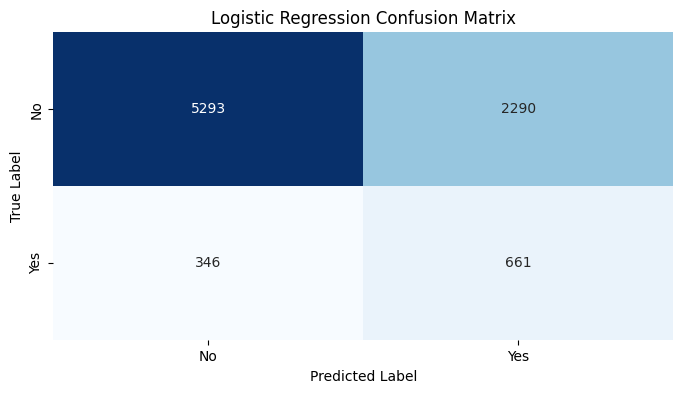

In [10]:
cm_lr = confusion_matrix(y_test, y_pred_final)

labels = ['No', 'Yes']

plt.figure(figsize=(8, 4))

sns.heatmap(cm_lr, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar=False)

plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [11]:
results = []

lr_results = {
    'Model': 'Logistic Regression (w/ SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall': recall_score(y_test, y_pred_final),
    'F1-Score': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_final)
}

results.append(lr_results)

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (w/ SMOTE),0.693132,0.223992,0.656405,0.334007,0.743897


#### Pipeline (Preprocessing, balancing classes with UnderSampling, training with KFold and tuning with Bayesian Optimization)

In [12]:
preprocessor_scaling = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous_vars),
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

space = {
    'classifier__C': hp.loguniform('C', np.log(1e-6), np.log(1e+6)),
    'classifier__penalty': hp.choice('penalty', ['l1', 'l2']),
    'classifier__solver': hp.choice('solver', ['liblinear', 'saga'])
}

def objective(params):
    pipeline_lr = ImbPipeline(steps=[
        ('preprocessor', preprocessor_scaling),
        ('resampler', RandomUnderSampler(random_state=42)),
        ('classifier', LogisticRegression(random_state=42, max_iter=3000))
    ])
    
    pipeline_lr.set_params(**params)
    
    # Kfold
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    score = cross_val_score(pipeline_lr, X_train, y_train, cv=kfold, scoring='roc_auc', n_jobs=-1).mean()    
    loss = -score
    
    return {'loss': loss, 'status': STATUS_OK}

trials = Trials()
best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials
)

print("Bayesian Optmization concluded.")

 10%|█         | 2/20 [00:03<00:31,  1.77s/trial, best loss: -0.7396998303214065]

/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/co

 15%|█▌        | 3/20 [00:05<00:37,  2.21s/trial, best loss: -0.7396999939474913]

/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/co

 20%|██        | 4/20 [00:09<00:42,  2.66s/trial, best loss: -0.7396999939474913]

...

 80%|████████  | 16/20 [00:32<00:05,  1.47s/trial, best loss: -0.7428611040721996]

/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/co

 90%|█████████ | 18/20 [00:35<00:03,  1.71s/trial, best loss: -0.7428611040721996]

/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/comgas-bank-marketing/venv-comgas-code-exercise/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/guilhermegarcia/GitHub/co

100%|██████████| 20/20 [00:39<00:00,  1.96s/trial, best loss: -0.7428611040721996]
Bayesian Optmization concluded.


In [13]:
best_penalty = ['l1', 'l2'][best_params['penalty']]
best_solver = ['liblinear', 'saga'][best_params['solver']]
best_C = best_params['C']

final_params = {
    'classifier__C': best_C,
    'classifier__penalty': best_penalty,
    'classifier__solver': best_solver
}

final_pipeline_lr = ImbPipeline(steps=[
    ('preprocessor', preprocessor_scaling),
    ('resampler', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=3000))
])

final_pipeline_lr.set_params(**final_params)
final_pipeline_lr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['age', 'balance', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'oct',
                                                                              'nov',
                                                                              'dec']]),
                                                  ['education', 'month'])])),
                ('resampler', RandomUnderSampler(random_state=42)),
                ('classifier',
                 LogisticRegression(C=18309.27389949125, max_iter=3000,
                                    random_state=42, solver='liblinear'))])

##### Evaluation

In [14]:
final_pipeline_lr.fit(X_train, y_train)
y_pred_final = final_pipeline_lr.predict(X_test)
y_pred_proba_final = final_pipeline_lr.predict_proba(X_test)[:, 1]

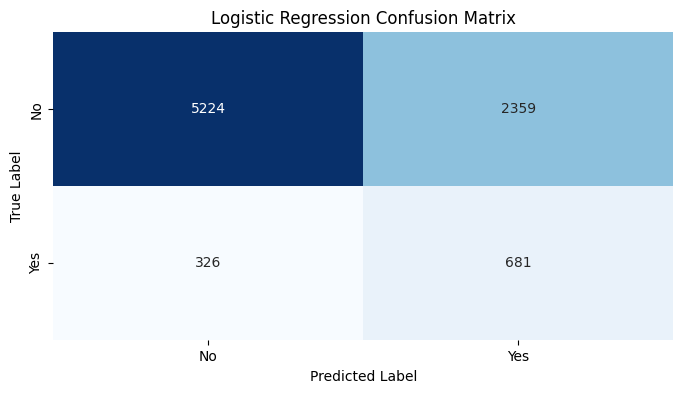

In [15]:
cm_lr = confusion_matrix(y_test, y_pred_final)

labels = ['No', 'Yes']

plt.figure(figsize=(8, 4))

sns.heatmap(cm_lr, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar=False)

plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [16]:
lr_results = {
    'Model': 'Logistic Regression (w/ RandomUnderSampler)',
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall': recall_score(y_test, y_pred_final),
    'F1-Score': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_final)
}

results_df.loc[len(results_df)] = lr_results
results_df.sort_values(by=['Recall'], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression (w/ RandomUnderSampler),0.687427,0.224013,0.676266,0.336546,0.746076
0,Logistic Regression (w/ SMOTE),0.693132,0.223992,0.656405,0.334007,0.743897


### KNN

The K-Nearest Neighbors (KNN) algorithm was implemented as a non-linear alternative to the baseline model. As a distance-based classifier, its performance is highly dependent on the geometry of the feature space, making a robust preprocessing pipeline essential.

To maximize its potential and address the model's requirements, the same preprocessing pipeline as from Logistic Regression was applied before training with KFold, especially because, for KNN, as the algorithm relies on calculating distances between data points. Without scaling, features with larger ranges would unfairly dominate these calculations and bias the model. As well as feature encoding the categorical variables to allow the distance metrics used by KNN to be calculated across all dimensions of the feature space. Class Imbalance was also handled using the SMOTE and RandomUnderSampler techniques.

The model was trained using StratifiedKFold cross-validation. Key hyperparameters, such as the number of neighbors (n_neighbors) and the distance metric, were tuned using Bayesian optimization to find the best possible configuration.

A noteworthy result from the Bayesian optimization was the selection of the Manhattan distance (metric='manhattan') as the optimal metric. A good reason for this outcome relates directly to the high-dimensional nature of the preprocessed feature space. In such scenarios, the Euclidean distance (the straight-line path) can sometimes be less effective, as the concept of a "close" neighbor becomes less intuitive.

#### Pipeline (Preprocessing, balancing classes with OverSampling, training with KFold and tuning with Bayesian Optimization)

In [17]:
preprocessor_scaling = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous_vars),
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

space_knn = {
    'classifier__n_neighbors': hp.quniform('n_neighbors', 3, 20, 2), # K de 3 a 31, em passos de 2 (apenas ímpares)
    'classifier__weights': hp.choice('weights', ['uniform', 'distance']),
    'classifier__metric': hp.choice('metric', ['euclidean', 'manhattan', 'minkowski'])
}

def objective_knn(params):
    params['classifier__n_neighbors'] = int(params['classifier__n_neighbors'])
    
    pipeline_knn = ImbPipeline(steps=[
        ('preprocessor', preprocessor_scaling),
        ('resampler', SMOTE(random_state=42)),
        ('classifier', KNeighborsClassifier())
    ])
    
    pipeline_knn.set_params(**params)
    
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(pipeline_knn, X_train, y_train, cv=kfold, scoring='roc_auc', n_jobs=-1).mean()    
    loss = -score
    
    return {'loss': loss, 'status': STATUS_OK}

trials_knn = Trials()
best_params_knn = fmin(
    fn=objective_knn,
    space=space_knn,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_knn
)

print("Bayesian Optmization concluded.")

100%|██████████| 50/50 [01:33<00:00,  1.87s/trial, best loss: -0.7409124981585429]
Bayesian Optmization concluded.


In [18]:
best_params_knn_values = {
    'classifier__n_neighbors': int(best_params_knn['n_neighbors']),
    'classifier__weights': ['uniform', 'distance'][best_params_knn['weights']],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski'][best_params_knn['metric']]
}

final_pipeline_knn = ImbPipeline(steps=[
    ('preprocessor', preprocessor_scaling),
    ('resampler', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier())
])

final_pipeline_knn.set_params(**best_params_knn_values)
final_pipeline_knn

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['age', 'balance', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'oct',
                                                                              'nov',
                                                                              'dec']]),
                                                  ['education', 'month'])])),
                ('resampler', SMOTE(random_state=42)),
                ('classifier',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=20))])

##### Evaluation

In [19]:
final_pipeline_knn.fit(X_train, y_train)
y_pred_knn = final_pipeline_knn.predict(X_test)
y_pred_proba_knn = final_pipeline_knn.predict_proba(X_test)[:, 1]

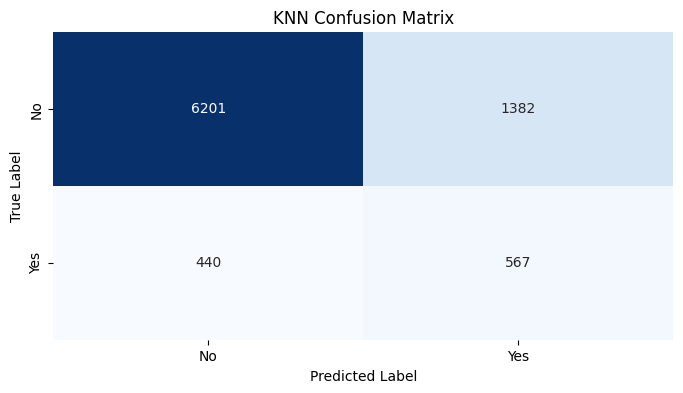

In [20]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

labels = ['No', 'Yes']

plt.figure(figsize=(8, 4))

sns.heatmap(cm_knn, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar=False)

plt.title('KNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [21]:
knn_results = {
    'Model': 'KNeighborsClassifier (w/ SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_knn)
}

results_df.loc[len(results_df)] = knn_results
results_df.sort_values(by=['Recall'], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression (w/ RandomUnderSampler),0.687427,0.224013,0.676266,0.336546,0.746076
0,Logistic Regression (w/ SMOTE),0.693132,0.223992,0.656405,0.334007,0.743897
2,KNeighborsClassifier (w/ SMOTE),0.787893,0.290918,0.563059,0.383627,0.743159


#### Pipeline (Preprocessing, balancing classes with UnderSampling, training with KFold and tuning with Bayesian Optimization)

In [22]:
preprocessor_scaling = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous_vars),
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

space_knn = {
    'classifier__n_neighbors': hp.quniform('n_neighbors', 3, 20, 2), # K de 3 a 31, em passos de 2 (apenas ímpares)
    'classifier__weights': hp.choice('weights', ['uniform', 'distance']),
    'classifier__metric': hp.choice('metric', ['euclidean', 'manhattan', 'minkowski'])
}

def objective_knn(params):
    params['classifier__n_neighbors'] = int(params['classifier__n_neighbors'])
    
    pipeline_knn = ImbPipeline(steps=[
        ('preprocessor', preprocessor_scaling),
        ('resampler', RandomUnderSampler(random_state=42)),
        ('classifier', KNeighborsClassifier())
    ])
    
    pipeline_knn.set_params(**params)
    
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(pipeline_knn, X_train, y_train, cv=kfold, scoring='roc_auc', n_jobs=-1).mean()    
    loss = -score
    
    return {'loss': loss, 'status': STATUS_OK}

trials_knn = Trials()
best_params_knn = fmin(
    fn=objective_knn,
    space=space_knn,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_knn
)

print("Bayesian Optmization concluded.")

100%|██████████| 50/50 [00:22<00:00,  2.25trial/s, best loss: -0.7587898144490921]
Bayesian Optmization concluded.


In [23]:
best_params_knn_values = {
    'classifier__n_neighbors': int(best_params_knn['n_neighbors']),
    'classifier__weights': ['uniform', 'distance'][best_params_knn['weights']],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski'][best_params_knn['metric']]
}

final_pipeline_knn = ImbPipeline(steps=[
    ('preprocessor', preprocessor_scaling),
    ('resampler', RandomUnderSampler(random_state=42)),
    ('classifier', KNeighborsClassifier())
])

final_pipeline_knn.set_params(**best_params_knn_values)
final_pipeline_knn

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['age', 'balance', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'oct',
                                                                              'nov',
                                                                              'dec']]),
                                                  ['education', 'month'])])),
                ('resampler', RandomUnderSampler(random_state=42)),
                ('classifier',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=20,
                                      weights='distance'))])

##### Evaluation

In [24]:
final_pipeline_knn.fit(X_train, y_train)
y_pred_knn = final_pipeline_knn.predict(X_test)
y_pred_proba_knn = final_pipeline_knn.predict_proba(X_test)[:, 1]

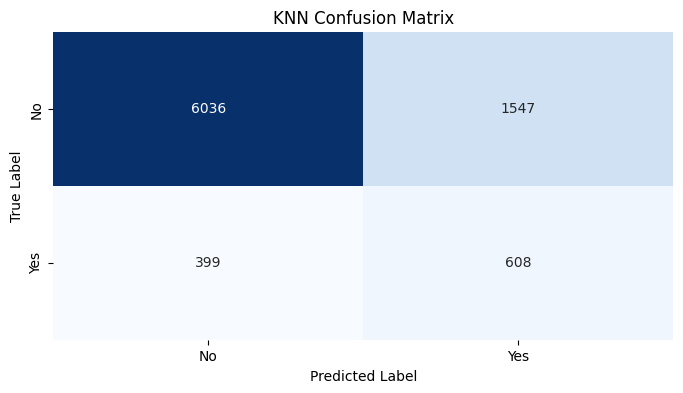

In [25]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

labels = ['No', 'Yes']

plt.figure(figsize=(8, 4))

sns.heatmap(cm_knn, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar=False)

plt.title('KNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [26]:
knn_results = {
    'Model': 'KNeighborsClassifier (w/ RandomUnderSampler)',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_knn)
}

results_df.loc[len(results_df)] = knn_results
results_df.sort_values(by=['Recall'], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression (w/ RandomUnderSampler),0.687427,0.224013,0.676266,0.336546,0.746076
0,Logistic Regression (w/ SMOTE),0.693132,0.223992,0.656405,0.334007,0.743897
3,KNeighborsClassifier (w/ RandomUnderSampler),0.773458,0.282135,0.603774,0.384567,0.759250
2,KNeighborsClassifier (w/ SMOTE),0.787893,0.290918,0.563059,0.383627,0.743159


### Random Forest

The Random Forest algorithm was implemented as a non-linear ensemble model. As a tree-based method, its preprocessing requirements differ significantly from linear and distance-based models, allowing for a more direct approach to handling the data.

To maximize its potential and align with the model's strengths, the feature scaling was ommited (As it will be for the following models LGBM and XGBClassifier), since these type of algoritmns operates by making decisions based on thresholds (splits) rather than magnitudes, making it naturally insensitive to the scale of the continuous variables. 

OneHotEncoder and OrdinalEncoder were still required to convert all categorical features into a numerical format, as the algorithm cannot process text-based labels.

Finally, the class imbalance was handled by setting the class_weight='balanced' parameter directly within the model. This built-in method automatically adjusts the weights inversely proportional to class frequencies, giving more importance to the minority class without altering the training data through resampling techniques like SMOTE/RandomUnderSampling.

#### Pipeline (Preprocessing categorical features, balancing classes with Class Weight, training with KFold and tuning with Bayesian Optimization)

In [27]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

space_rf = {
    'classifier__n_estimators': hp.quniform('n_estimators', 100, 1000, 50), # Nº de árvores
    'classifier__max_depth': hp.quniform('max_depth', 10, 50, 1),           # Profundidade máxima
    'classifier__min_samples_split': hp.quniform('min_samples_split', 2, 20, 1), # Mínimo de amostras para dividir um nó
    'classifier__min_samples_leaf': hp.quniform('min_samples_leaf', 1, 20, 1)   # Mínimo de amostras em uma folha
}

def objective_rf(params):
    for param in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']:
        params['classifier__' + param] = int(params['classifier__' + param])
    
    pipeline_rf = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('classifier', RandomForestClassifier(
            random_state=42, 
            n_jobs=-1,
            class_weight='balanced'
        ))
    ])
    
    pipeline_rf.set_params(**params)
    
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(pipeline_rf, X_train, y_train, cv=kfold, scoring='roc_auc', n_jobs=-1).mean()    
    loss = -score
    
    return {'loss': loss, 'status': STATUS_OK}

trials_rf = Trials()
best_params_rf = fmin(
    fn=objective_rf,
    space=space_rf,
    algo=tpe.suggest,
    max_evals=40,
    trials=trials_rf
)

print("Bayesian Optmization concluded.")

100%|██████████| 40/40 [03:07<00:00,  4.70s/trial, best loss: -0.7914982441414312]
Bayesian Optmization concluded.


In [28]:
best_params_rf_values = {
    'classifier__n_estimators': int(best_params_rf['n_estimators']),
    'classifier__max_depth': int(best_params_rf['max_depth']),
    'classifier__min_samples_split': int(best_params_rf['min_samples_split']),
    'classifier__min_samples_leaf': int(best_params_rf['min_samples_leaf'])
}

final_pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced'
    ))
])

final_pipeline_rf.set_params(**best_params_rf_values)
final_pipeline_rf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'oct',
                                                                              'nov',
                                                                              'dec']]),
                                                  ['education', 'month'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=3,
                                        min_samples_split=15, n_estimators=900,
                                        n_jobs=-1, random_state=42))])

##### Evaluation

In [29]:
final_pipeline_rf.fit(X_train, y_train)
y_pred_rf = final_pipeline_rf.predict(X_test)
y_pred_proba_rf = final_pipeline_rf.predict_proba(X_test)[:, 1]

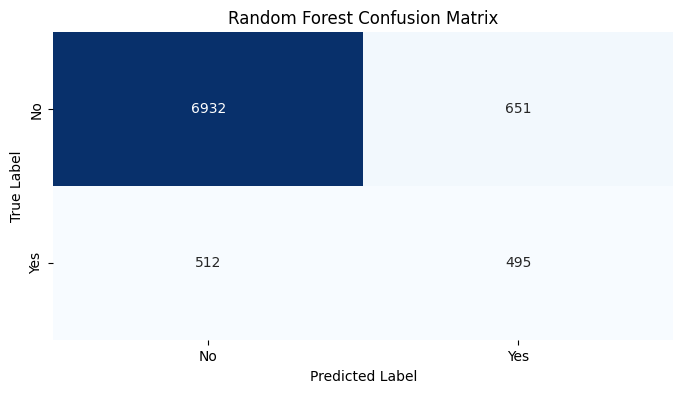

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

labels = ['No', 'Yes']

plt.figure(figsize=(8, 4))

sns.heatmap(cm_rf, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar=False)

plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [31]:
rf_results = {
    'Model': 'RandomForest (w/ Balanced Weights)',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf)
}

results_df.loc[len(results_df)] = rf_results
results_df.sort_values(by=['Recall'], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression (w/ RandomUnderSampler),0.687427,0.224013,0.676266,0.336546,0.746076
0,Logistic Regression (w/ SMOTE),0.693132,0.223992,0.656405,0.334007,0.743897
3,KNeighborsClassifier (w/ RandomUnderSampler),0.773458,0.282135,0.603774,0.384567,0.759250
2,KNeighborsClassifier (w/ SMOTE),0.787893,0.290918,0.563059,0.383627,0.743159
4,RandomForest (w/ Balanced Weights),0.864610,0.431937,0.491559,0.459824,0.791700


### Light Gradient Boosting Machine (LGBM)

The LightGBM model was implemented as an advanced gradient boosting ensemble, known for its high performance and training speed. As a modern tree-based algorithm, its preprocessing requirements are similar to those of Random Forest. To maximize its potential and leverage its capabilities, the same preprocessing pipeline from RandomForest was applied before training with KFold.

Its important mentioning that the training methodology is still different from that of Random Forest. While Random Forest builds many independent trees in parallel and combines their results through voting (Bagging), LGBM is a sequential ensemble (Boosting).

Since model's nature, the class imbalance was addressed by utilizing the model's built-in class_weight='balanced' parameter. This method adjusts the importance of the minority class during the gradient boosting process, allowing the model to learn its patterns effectively.

#### Pipeline (Preprocessing categorical features, balancing classes with Class Weight, training with KFold and tuning with Bayesian Optimization)

In [32]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

space_lgbm = {
    'classifier__n_estimators': hp.quniform('n_estimators', 200, 1500, 50),
    'classifier__learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'classifier__max_depth': hp.quniform('max_depth', 5, 30, 1),
    'classifier__num_leaves': hp.quniform('num_leaves', 20, 100, 5), # Chave para o LGBM
    'classifier__reg_alpha': hp.uniform('reg_alpha', 0.0, 1.0), # Regularização L1
    'classifier__reg_lambda': hp.uniform('reg_lambda', 0.0, 1.0) # Regularização L2
}

def objective_lgbm(params):
    for param in ['n_estimators', 'max_depth', 'num_leaves']:
        params['classifier__' + param] = int(params['classifier__' + param])
    
    pipeline_lgbm = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('classifier', LGBMClassifier(
            random_state=42, 
            n_jobs=-1,
            class_weight='balanced', verbose=-1
        ))
    ])
    
    pipeline_lgbm.set_params(**params)
    
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(pipeline_lgbm, X_train, y_train, cv=kfold, scoring='roc_auc', n_jobs=-1).mean()    
    loss = -score
    
    return {'loss': loss, 'status': STATUS_OK, 'params': params}

trials_lgbm = Trials()
best_params_lgbm = fmin(
    fn=objective_lgbm,
    space=space_lgbm,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials_lgbm
)

print("Bayesian Optmization concluded.")

100%|██████████| 20/20 [38:22<00:00, 115.10s/trial, best loss: -0.7975274306865673]
Bayesian Optmization concluded.


In [33]:
best_params_lgbm_values = trials_lgbm.best_trial['result']['params']

final_pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', LGBMClassifier(
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced',
        verbosity=-1
    ))
])

final_pipeline_lgbm.set_params(**best_params_lgbm_values)
final_pipeline_lgbm

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'oct',
                                                                              'nov',
                                                                              'dec']]),
                                                  ['education', 'month'])])),
                ('classifier',
                 LGBMClassifier(class_weight='balanced',
                                learning_rate=0.014625801445469828,
                                max_depth=25, n_estimators=250, n_jobs=-1,
                                num_leaves=75, random_state=42,
                                reg_alpha=0.8365031145645383,
                                reg_lambda=0.7393956139969868, verbosity=-1))])

##### Evaluation

In [34]:
final_pipeline_lgbm.fit(X_train, y_train)

y_pred_lgbm = final_pipeline_lgbm.predict(X_test)
y_pred_proba_lgbm = final_pipeline_lgbm.predict_proba(X_test)[:, 1]

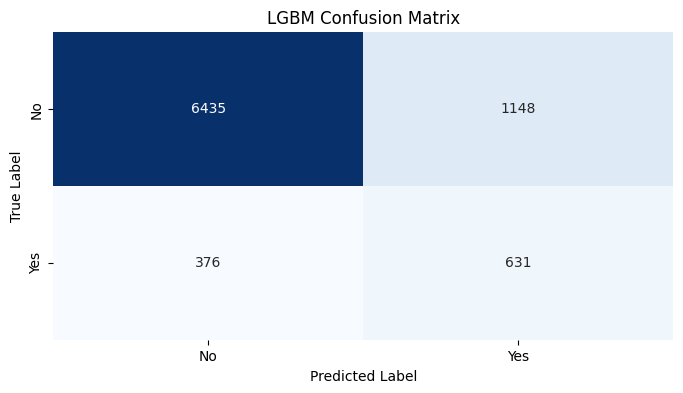

In [35]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

labels = ['No', 'Yes']

plt.figure(figsize=(8, 4))

sns.heatmap(cm_lgbm, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar=False)

plt.title('LGBM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [36]:
lgbm_results = {
    'Model': 'LightGBM (w/ Balanced Weights)',
    'Accuracy': accuracy_score(y_test, y_pred_lgbm),
    'Precision': precision_score(y_test, y_pred_lgbm),
    'Recall': recall_score(y_test, y_pred_lgbm),
    'F1-Score': f1_score(y_test, y_pred_lgbm),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_lgbm)
}

results_df.loc[len(results_df)] = lgbm_results
results_df.sort_values(by=['Recall'], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression (w/ RandomUnderSampler),0.687427,0.224013,0.676266,0.336546,0.746076
0,Logistic Regression (w/ SMOTE),0.693132,0.223992,0.656405,0.334007,0.743897
5,LightGBM (w/ Balanced Weights),0.822584,0.354694,0.626614,0.452979,0.802205
3,KNeighborsClassifier (w/ RandomUnderSampler),0.773458,0.282135,0.603774,0.384567,0.759250
2,KNeighborsClassifier (w/ SMOTE),0.787893,0.290918,0.563059,0.383627,0.743159
4,RandomForest (w/ Balanced Weights),0.864610,0.431937,0.491559,0.459824,0.791700


### XGBClassifier

Finally, the XGBoost (eXtreme Gradient Boosting) classifier was implemented, representing another state-of-the-art gradient boosting ensemble. Similar to LightGBM, XGBoost builds trees in a sequential manner, where each new tree is trained to correct the errors made by the previous ones. A key feature that distinguishes XGBoost is its advanced implementation of built-in regularization (L1 and L2), which provides robust control over model complexity to prevent overfitting.

To optimize its performance, the following pipeline was applied before training with KFold:

Feature Scaling: As XGBoost is a tree-based algorithm, this step was omitted. The model's performance is not influenced by the scale of the numerical features because its splitting criteria are based on thresholds.

Feature Encoding: The standard pipeline of using OneHotEncoder and OrdinalEncoder was applied to convert all categorical features into a necessary numerical format that the model can process.

Class Imbalance: The class imbalance was addressed using the scale_pos_weight parameter. This technique assigns a higher penalty to errors made on the minority class, effectively compelling the model to focus more on correctly identifying the positive instances during training.

#### Pipeline (Preprocessing categorical features, balancing classes with Scale Pos Weight, training with KFold and tuning with Bayesian Optimization)

In [37]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

space_xgb = {
    'classifier__n_estimators': hp.quniform('n_estimators', 200, 1500, 50),
    'classifier__learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'classifier__max_depth': hp.quniform('max_depth', 3, 15, 1),
    'classifier__subsample': hp.uniform('subsample', 0.7, 1.0),
    'classifier__colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'classifier__gamma': hp.uniform('gamma', 0.0, 0.5)
}

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

def objective_xgb(params):
    for param in ['n_estimators', 'max_depth']:
        params['classifier__' + param] = int(params['classifier__' + param])
    
    pipeline_xgb = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('classifier', XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric='logloss'
        ))
    ])
    
    pipeline_xgb.set_params(**params)
    
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(pipeline_xgb, X_train, y_train, cv=kfold, scoring='roc_auc', n_jobs=-1).mean()
    loss = -score
    
    return {'loss': loss, 'status': STATUS_OK, 'params': params}

trials_xgb = Trials()
best_params_xgb = fmin(
    fn=objective_xgb,
    space=space_xgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_xgb
)

print("Bayesian Optmization concluded.")

100%|██████████| 50/50 [01:09<00:00,  1.39s/trial, best loss: -0.7981640849820273]
Bayesian Optmization concluded.


In [38]:
best_params_xgb_values = trials_xgb.best_trial['result']['params']

final_pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

final_pipeline_xgb.set_params(**best_params_xgb_values)
final_pipeline_xgb

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'o...
                               gamma=0.12936482660423065, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.013576870381412717, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=900,
                               n_jobs=None, num_parallel_tree=None, ...))])

##### Evaluation

In [39]:
final_pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = final_pipeline_xgb.predict(X_test)
y_pred_proba_xgb = final_pipeline_xgb.predict_proba(X_test)[:, 1]

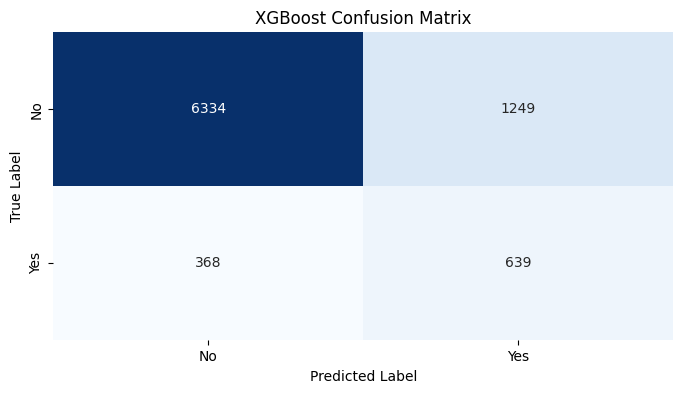

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

labels = ['No', 'Yes']

plt.figure(figsize=(8, 4))

sns.heatmap(cm_xgb, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar=False)

plt.title('XGBClassifier Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [ ]:
xgb_results = {
    'Model': 'XGBClassifier (w/ Balanced Weights)',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_xgb)
}

results_df.loc[len(results_df)] = xgb_results
results_df.sort_values(by=['Recall'], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression (w/ RandomUnderSampler),0.687427,0.224013,0.676266,0.336546,0.746076
0,Logistic Regression (w/ SMOTE),0.693132,0.223992,0.656405,0.334007,0.743897
6,XGBoost (w/ Balanced Weights),0.811758,0.338453,0.634558,0.441451,0.799323
5,LightGBM (w/ Balanced Weights),0.822584,0.354694,0.626614,0.452979,0.802205
3,KNeighborsClassifier (w/ RandomUnderSampler),0.773458,0.282135,0.603774,0.384567,0.759250
2,KNeighborsClassifier (w/ SMOTE),0.787893,0.290918,0.563059,0.383627,0.743159
4,RandomForest (w/ Balanced Weights),0.864610,0.431937,0.491559,0.459824,0.791700


#### Pipeline (Preprocessing categorical features, balancing classes with UnderSampling, training with KFold and tuning with Bayesian Optimization)

In [42]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

space_xgb = {
    'classifier__n_estimators': hp.quniform('n_estimators', 200, 1500, 50),
    'classifier__learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'classifier__max_depth': hp.quniform('max_depth', 3, 15, 1),
    'classifier__subsample': hp.uniform('subsample', 0.7, 1.0),
    'classifier__colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'classifier__gamma': hp.uniform('gamma', 0.0, 0.5)
}

def objective_xgb(params):
    for param in ['n_estimators', 'max_depth']:
        params['classifier__' + param] = int(params['classifier__' + param])
        
    pipeline_xgb = ImbPipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('resampler', RandomUnderSampler(random_state=42)),
        ('classifier', XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        ))
    ])
    
    pipeline_xgb.set_params(**params)
    
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(pipeline_xgb, X_train, y_train, cv=kfold, scoring='roc_auc', n_jobs=-1).mean()
    loss = -score
    
    return {'loss': loss, 'status': STATUS_OK, 'params': params}

trials_xgb = Trials()
best_params_xgb = fmin(
    fn=objective_xgb,
    space=space_xgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_xgb
)

print("Bayesian Optmization concluded.")

100%|██████████| 50/50 [00:34<00:00,  1.47trial/s, best loss: -0.7929373454173568]
Bayesian Optmization concluded.


In [43]:
best_params_xgb_values = trials_xgb.best_trial['result']['params']

final_pipeline_xgb = ImbPipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('resampler', RandomUnderSampler(random_state=42)),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

final_pipeline_xgb.set_params(**best_params_xgb_values)
final_pipeline_xgb

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'o...
                               gamma=0.2507776631618843, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.010133277832422946, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=1200,
                               n_jobs=None, num_parallel_tree=None, ...))])

##### Evaluation

In [44]:
final_pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = final_pipeline_xgb.predict(X_test)
y_pred_proba_xgb = final_pipeline_xgb.predict_proba(X_test)[:, 1]

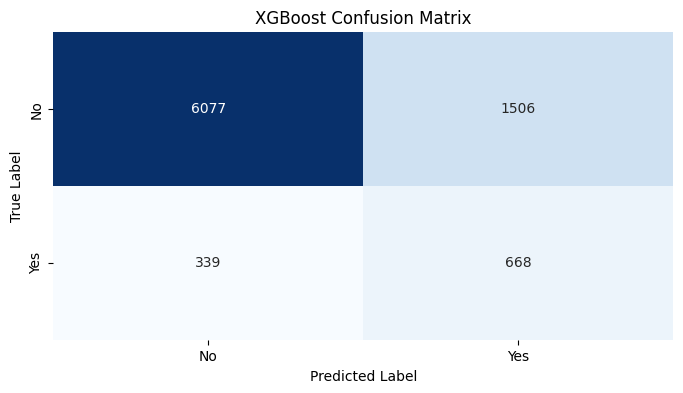

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

labels = ['No', 'Yes']

plt.figure(figsize=(8, 4))

sns.heatmap(cm_xgb, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar=False)

plt.title('XGBClassifier Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

### Comparison Results

#### Primary Metric Selection: Recall

For this case, `Recall` was chosen as the main metric to optimize and evaluate the models. This decision is based on a careful analysis of the costs associated with the two types of prediction errors:

- A False Positive occurs when the model predicts a customer will subscribe, but they do not. The business cost of this error is relatively low: an uninterested customer may receive additional marketing materials, which could lead to minor annoyance and some wasted marketing budget.

- A False Negative occurs when the model predicts a customer will not subscribe, but in reality, they were interested. The business cost of this error is significantly higher. It represents a direct loss of a revenue opportunity. Furthermore, failing to engage with an interested customer can lead to dissatisfaction and damage the client relationship, potentially causing them to take their business to a competitor.

Given that the cost of a missed opportunity (a False Negative) is substantially greater than the cost of targeting an uninterested customer (a False Positive), the strategic priority is to minimize False Negatives.

#### Models Comparison Results
- The Logistic Regression model, despite being the simplest linear algorithm, surprisingly achieved the highest Recall score. However, it is crucial to acknowledge the highest trade-off compared to the other algorithms: a high Recall is accompanied by the lowest Precision among others.
- The Gradient Boosting models, XGBoost and LGBM, are strong competitors, delivering a good overall performance. Their lower Recall compared to Logistic Regression can be attributed to the different imbalance handling strategy used (scale_pos_weight and class_weight). Perhaps, these methods results in a more conservative decision boundary, as they adjust the model's loss function rather than the data distribution itself. Furthermore, the hyperparameter tuning was optimized for ROC-AUC, a metric that balances True and False Positive rates, not exclusively for Recall.
- Regarding the models with the lowest rankings, KNN and Random Forest: The KNN model's performance was likely hindered by the high-dimensional feature space created after One-Hot Encoding. In such a large number of dimensions, distance-based calculations become less reliable, making it difficult for the algorithm to form meaningful neighborhoods. The Random Forest model, while typically powerful, may have created overly specific rules that did not generalize as effectively for identifying borderline positive cases, leading to a higher number of False Negatives. It is also possible that the class_weight='balanced' strategy was less aggressive in promoting recall compared to the data-level augmentation provided by Over Sampling/Under Sampling techniques.

In [ ]:
xgb_results = {
    'Model': 'XGBClassifier (w/ RandomUnderSampler)',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_xgb)
}

results_df.loc[len(results_df)] = xgb_results
results_df.sort_values(by=['Recall'], ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression (w/ RandomUnderSampler),0.687427,0.224013,0.676266,0.336546,0.746076
7,XGBoost (w/ RandomUnderSampler),0.785215,0.307268,0.663357,0.419994,0.797768
0,Logistic Regression (w/ SMOTE),0.693132,0.223992,0.656405,0.334007,0.743897
6,XGBoost (w/ Balanced Weights),0.811758,0.338453,0.634558,0.441451,0.799323
5,LightGBM (w/ Balanced Weights),0.822584,0.354694,0.626614,0.452979,0.802205
3,KNeighborsClassifier (w/ RandomUnderSampler),0.773458,0.282135,0.603774,0.384567,0.759250
2,KNeighborsClassifier (w/ SMOTE),0.787893,0.290918,0.563059,0.383627,0.743159
4,RandomForest (w/ Balanced Weights),0.864610,0.431937,0.491559,0.459824,0.791700


## Final Model

Following a evaluation of all trained models, the `XGBClassifier`, configured with a class weighting strategy, will be choosed for deployment.

While the Logistic Regression model achieved a sligthly higher score on the primary metric, Recall, the XGBClassifier model demonstrated highly competitive performance and was ultimately selected for its superior overall robustness and suitability for a production environment.

As the XGBClassifier model addresses class imbalance using the scale_pos_weight parameter, this is a methodologically cleaner approach as it adjusts the model’s learning algorithm internally without altering the underlying data distribution.

As a gradient boosting model, XGBClassifier is more capable of capturing the complex, non-linear interactions between features that were identified during the Exploratory Data Analysis. While Logistic Regression provided a strong baseline, XGBClassifier's ability to model these nuances makes it a more powerful and likely more future-proof solution that can better adapt to subtle shifts in customer behavior over time.

Furthermore, the XGBClassifier model offered a more favorable balance between Recall and Precision. While maximizing Recall was the primary goal, it provides a high rate of lead capture while maintaining the Precision. This results in a more efficient and cost-effective marketing campaign by reducing the number of uninterested customers who would be incorrectly targeted.

In [ ]:
results_df[results_df['Model'].eq('XGBClassifier (w/ Balanced Weights)')]

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
6,XGBoost (w/ Balanced Weights),0.811758,0.338453,0.634558,0.441451,0.799323


#### Pipeline (Preprocessing categorical features, balancing classes with Scale Pos Weight, training with KFold and tuning with Bayesian Optimization)

In [49]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

best_hyperparameters = {'classifier__colsample_bytree': 0.7928653143275137,
 'classifier__gamma': 0.23772115255829476,
 'classifier__learning_rate': 0.016041145534715962,
 'classifier__max_depth': 4,
 'classifier__n_estimators': 900,
 'classifier__subsample': 0.9490911979150977}

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

final_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ))
])

final_model_pipeline.set_params(**best_hyperparameters)
final_model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'o...
                               gamma=0.23772115255829476, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.016041145534715962, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=4,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=900,
                               n_jobs=None, num_parallel_tree=None, ...))])

### Evaluation

In [50]:
final_model_pipeline.fit(X_train, y_train)

y_pred_train = final_model_pipeline.predict(X_train)
y_pred_proba_train = final_model_pipeline.predict_proba(X_train)[:, 1]

y_pred_test = final_model_pipeline.predict(X_test)
y_pred_proba_test = final_model_pipeline.predict_proba(X_test)[:, 1]

train_metrics = {
    'Accuracy': accuracy_score(y_train, y_pred_train),
    'Precision': precision_score(y_train, y_pred_train),
    'Recall': recall_score(y_train, y_pred_train),
    'F1-Score': f1_score(y_train, y_pred_train),
    'ROC-AUC': roc_auc_score(y_train, y_pred_proba_train)
}

test_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test),
    'Recall': recall_score(y_test, y_pred_test),
    'F1-Score': f1_score(y_test, y_pred_test),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_test)
}

final_results_df = pd.DataFrame([train_metrics, test_metrics], index=['Train', 'Test'])
final_results_df.T.style.format("{:.4f}")

,Train,Test
Accuracy,0.8164,0.8064
Precision,0.3538,0.3314
Recall,0.6843,0.6405
F1-Score,0.4665,0.4368
ROC-AUC,0.8392,0.7977


#### Confusion Matrix

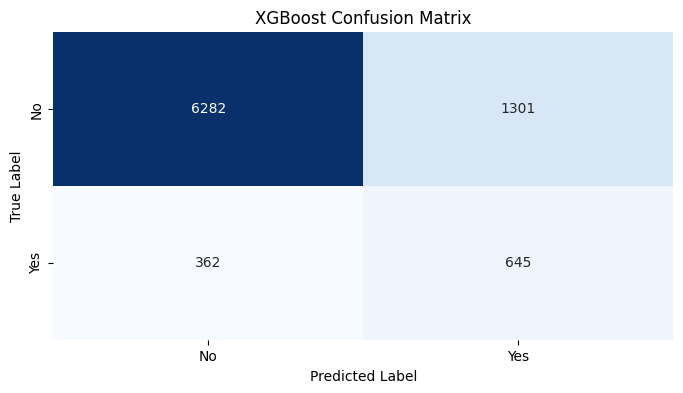

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_test)

labels = ['No', 'Yes']

plt.figure(figsize=(8, 4))

sns.heatmap(cm_xgb, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar=False)

plt.title('XGBClassifier Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

#### ROC Curve

The primary limitation of the ROC curve in this context is that it can be deceptively optimistic. The curve's x-axis represents the False Positive Rate (FPR). In this dataset, the number of True Negatives (TN), clients who are not interested and are correctly identified—is overwhelmingly large compared to the number of positives. So even if the model generates a considerable number of False Positives (incorrectly targeting uninterested clients), the FPR value can remain very low because the denominator of the formula is massive. This can keep the ROC curve artificially pushed to the top-left, suggesting a higher level of performance than is practically achieved in terms of marketing efficiency.

For this reason, while the ROC curve confirmed the model's fundamental predictive capability, it was not used for the final strategic decision. The Precision-Recall curve is more recommended for this evaluation because it provides a more direct and realistic assessment of the model's performance on the minority class, which is the focus of this business case.

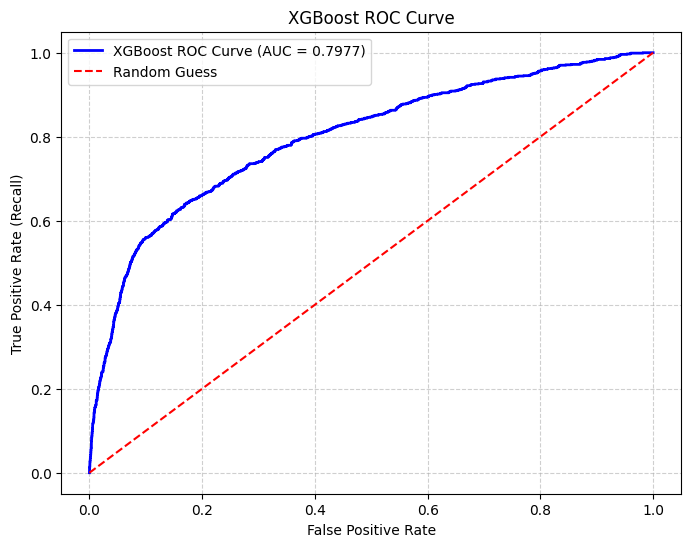

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
auc_score = roc_auc_score(y_test, y_pred_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBClassifier ROC Curve (AUC = {auc_score:.4f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('XGBClassifier ROC Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Precision-Recall Curve

The curve's core value lies in how it directly plots the relationship between Precision and Recall. It explicitly answers the central business question: "For each increase in our customer capture power (Recall), what will be the loss in our marketing 'hit rate' (Precision)?"

This visualization makes the trade-off tangible. As the model is adjusted to find a higher percentage of all potential subscribers, it must necessarily become less strict, which leads to a higher number of False Positives and thus a lower Precision. The PR curve allows the business to see exactly what that trade-off looks like at every possible threshold.

This enables informed, data-driven business decisions. For example, stakeholders can analyze the curve and conclude: "We can accept a Precision of 30%—meaning 70% of our targeted clients will not convert—if it guarantees that we are successfully identifying and contacting 80% of all customers who are genuinely interested." By translating the model's performance into a clear cost-benefit scenario, the Precision-Recall curve serves as the essential bridge between the data science outcome and the strategic objectives of the marketing campaign.

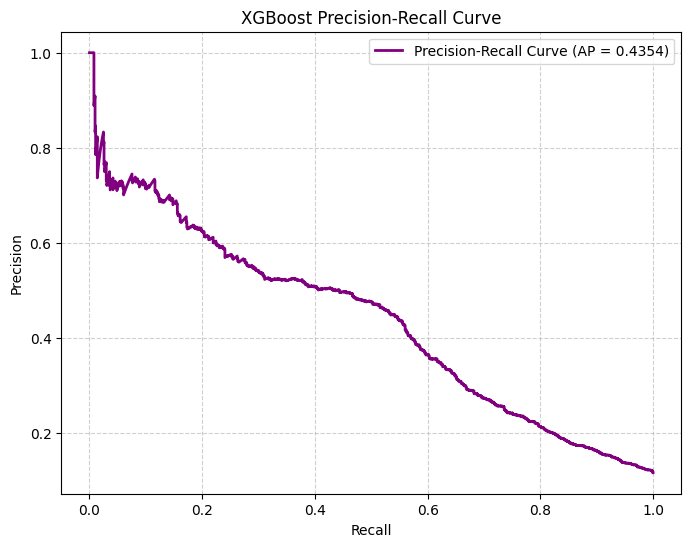

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_test)
avg_precision = average_precision_score(y_test, y_pred_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.4f})', color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBClassifier Precision-Recall Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Feature Importance

The results clearly indicated that poutcome_success is, by a significant margin, the most influential feature. This is a highly intuitive finding, confirming the business logic that a client's positive outcome in a previous campaign is the strongest single predictor of their willingness to subscribe again.

The analysis also revealed a long tail of features, including many dummy variables, that had very low importance scores. This suggested they contributed minimally to the model's predictive power and could be considered noise.

Based on these insights, a feature selection process was implemented. The objective is to retain only the most impactful variables for deployment, as it leads to a simpler, faster, and more interpretable model that is less prone to overfitting on irrelevant features.

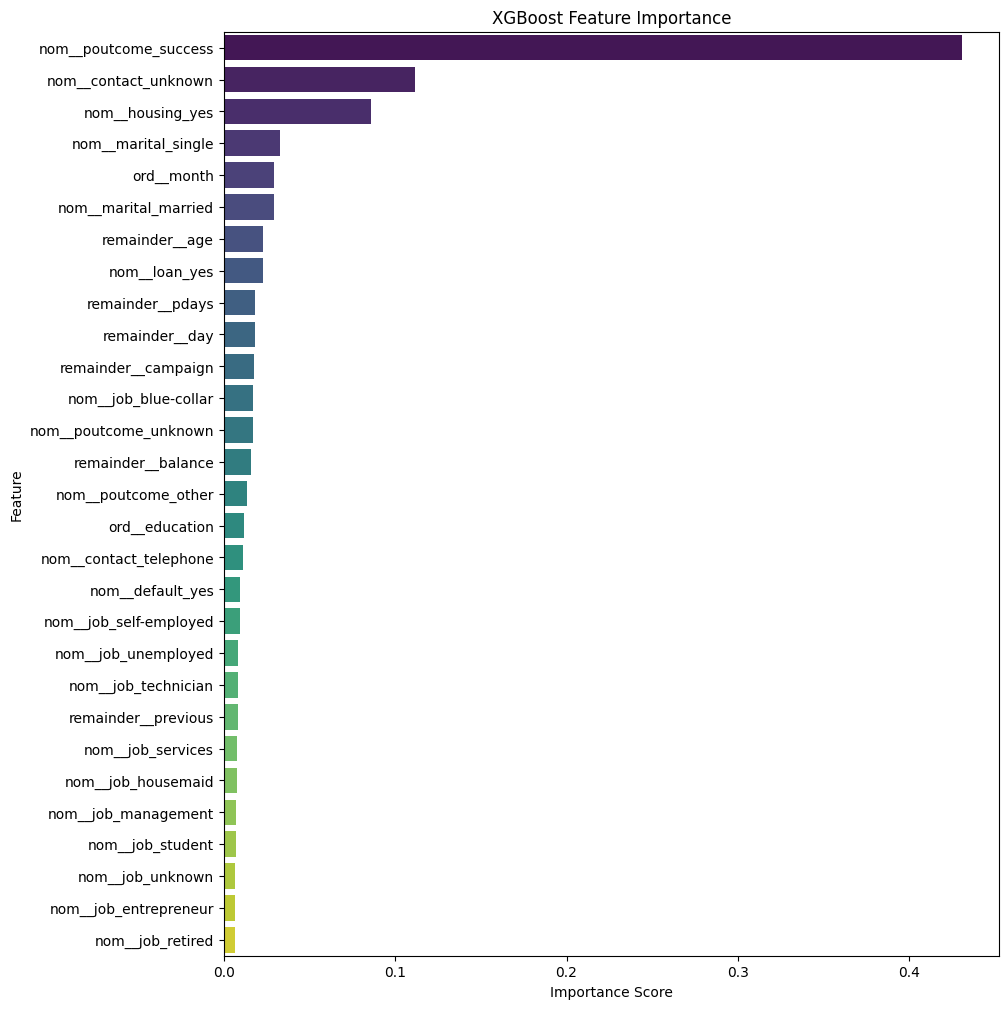

In [ ]:
feature_names = final_model_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = final_model_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis', hue='feature')
plt.title('XGBClassifier Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

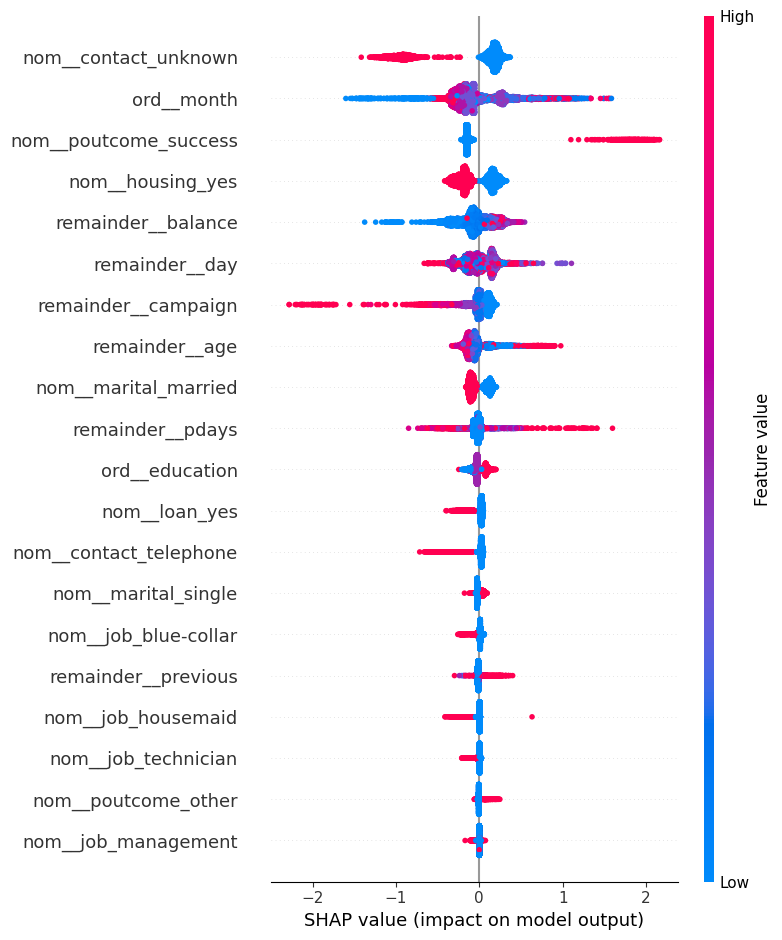

In [55]:
final_model = final_model_pipeline.named_steps['classifier']
preprocessor = final_model_pipeline.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_transformed_df)

shap.summary_plot(shap_values, X_test_transformed_df, plot_type='dot')

##### Feature Selection

In [56]:
selector = SelectFromModel(final_model, prefit=True, threshold="median")

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

X_train_selected = selector.transform(X_train_transformed)
X_test_selected = selector.transform(X_test_transformed)

print(f"Original Number of features: {X_train_transformed.shape[1]}")
print(f"Number of selected features: {X_train_selected.shape[1]}")

selected_feature_names = preprocessor.get_feature_names_out()[selector.get_support()]
print("\nSelected features:")
print(selected_feature_names)

Original Number of features: 29
Number of selected features: 15

Selected features:
['nom__job_blue-collar' 'nom__marital_married' 'nom__marital_single'
 'nom__contact_unknown' 'nom__poutcome_other' 'nom__poutcome_success'
 'nom__poutcome_unknown' 'nom__housing_yes' 'nom__loan_yes' 'ord__month'
 'remainder__age' 'remainder__balance' 'remainder__day'
 'remainder__campaign' 'remainder__pdays']


In [57]:
best_model_params = {k.replace('classifier__', ''): v for k, v in best_hyperparameters.items()}

best_model_params['random_state'] = 42
best_model_params['eval_metric'] = 'logloss'
best_model_params['scale_pos_weight'] = y_train.value_counts()[0] / y_train.value_counts()[1]

final_model_feature_selection = XGBClassifier(**best_model_params)

final_model_feature_selection.fit(X_train_selected, y_train)

y_pred_train_new = final_model_feature_selection.predict(X_train_selected)
y_pred_proba_train_new = final_model_feature_selection.predict_proba(X_train_selected)[:, 1]

y_pred_test_new = final_model_feature_selection.predict(X_test_selected)
y_pred_proba_test_new = final_model_feature_selection.predict_proba(X_test_selected)[:, 1]

train_metrics_new = {
    'Accuracy': accuracy_score(y_train, y_pred_train_new),
    'Precision': precision_score(y_train, y_pred_train_new),
    'Recall': recall_score(y_train, y_pred_train_new),
    'F1-Score': f1_score(y_train, y_pred_train_new),
    'ROC-AUC': roc_auc_score(y_train, y_pred_proba_train_new)}

test_metrics_new = {
    'Accuracy': accuracy_score(y_test, y_pred_test_new),
    'Precision': precision_score(y_test, y_pred_test_new),
    'Recall': recall_score(y_test, y_pred_test_new),
    'F1-Score': f1_score(y_test, y_pred_test_new),
    'ROC-AUC': roc_auc_score(y_test, y_pred_test_new)
}

final_model_feature_selection_results_df = pd.DataFrame([train_metrics_new, test_metrics_new], 
                                    index=['Train (Feature Selection)', 'Test (Feature Selection)'])

final_model_feature_selection_results_df.T.style.format("{:.4f}")

,Train (Feature Selection),Test (Feature Selection)
Accuracy,0.8156,0.8062
Precision,0.3511,0.3308
Recall,0.6754,0.6385
F1-Score,0.4620,0.4358
ROC-AUC,0.8349,0.7335


In [58]:
comparison_df_full = pd.concat([final_results_df, final_model_feature_selection_results_df])
comparison_df_full.T.style.format("{:.4f}")

,Train,Test,Train (Feature Selection),Test (Feature Selection)
Accuracy,0.8164,0.8064,0.8156,0.8062
Precision,0.3538,0.3314,0.3511,0.3308
Recall,0.6843,0.6405,0.6754,0.6385
F1-Score,0.4665,0.4368,0.4620,0.4358
ROC-AUC,0.8392,0.7977,0.8349,0.7335


### Save Model

In [66]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('nom', nominal_transformer, nominal_vars),
        ('ord', ordinal_transformer, ordinal_vars)],
    remainder='passthrough'
)

selector_estimator = XGBClassifier(random_state=42)

final_pipeline_feature_selection = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('selector', SelectFromModel(estimator=selector_estimator, threshold="median")),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])))
])

final_pipeline_feature_selection.set_params(**best_hyperparameters)
final_pipeline_feature_selection.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'default',
                                                   'housing', 'loan']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['primary',
                                                                              'secondary',
                                                                              'tertiary',
                                                                              'unknown'],
                                                                             ['jan',
                                                                              'feb',
                                                                              'mar',
                                                                              'apr',
                                                                              'may',
                                                                              'jun',
                                                                              'jul',
                                                                              'aug',
                                                                              'sep',
                                                                              'o...
                               gamma=0.23772115255829476, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.016041145534715962, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=4,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=900,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [67]:
# Pipeline
filename = "./deploy/artifacts/xgb_pipeline.pkl"

with open(filename, "wb") as file:
    pickle.dump(final_pipeline_feature_selection, file)

print(f"XGB Pipeline saved successfully as {filename}")

XGB Pipeline saved successfully as ./deploy/artifacts/xgb_pipeline.pkl
